## Amazon Alexa Review - Sentiment Analysis

### Alanyzing the Amazon Alexa dataset and building classification models to predict if the sentiment of a given input sentence is positive or negative.

In [1]:
## Importing Important libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download("stopwords")
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("english"))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from wordcloud import WordCloud
import pickle
import re

In [4]:
# load dataset
data = pd.read_csv("amazon_alexa.tsv",delimiter = "\t")
data

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1
...,...,...,...,...,...
3145,5,30-Jul-18,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,5,30-Jul-18,Black Dot,"Listening to music, searching locations, check...",1
3147,5,30-Jul-18,Black Dot,"I do love these things, i have them running my...",1
3148,5,30-Jul-18,White Dot,Only complaint I have is that the sound qualit...,1


## Data Cleaning

In [5]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [7]:
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [8]:
data.shape

(3150, 5)

## Exploratory Data Analysis

In [9]:
# How many positive and negative reviews are their
data['feedback'].value_counts()

feedback
1    2893
0     257
Name: count, dtype: int64

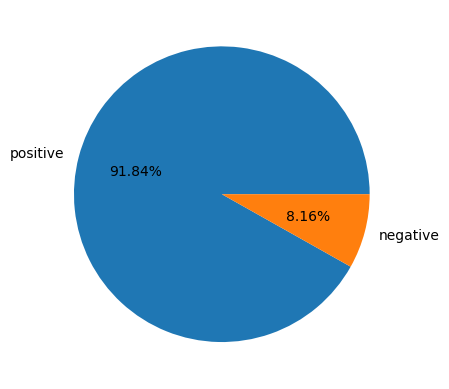

In [10]:
# Ploting a pie chart for the percentage distribution of target
plt.pie(data['feedback'].value_counts(),labels=['positive','negative'],autopct='%0.2f%%')
plt.show()

In [11]:
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [12]:
data['feedback'].value_counts()

feedback
1    2893
0     257
Name: count, dtype: int64

In [13]:
# Check the null value
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [14]:
# Getting the record where "verified_reviews" is null
data[data["verified_reviews"].isna()==True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [15]:
# We will drop the null record
data.dropna(inplace=True)

In [16]:
print(f"Dataset shape after dropping null values : {data.shape}")

Dataset shape after dropping null values : (3149, 5)


In [17]:
# Creating a new column "length" that will contain the length of the string in "verified_reviews" column

data['length'] = data['verified_reviews'].apply(len)

In [18]:
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,195
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [19]:
### The length 'column' is new generated column-stores the length of verified_reviews for that record. Let's check for some sample records

In [20]:
# Randomly checking for 10th record

print(f"'verified_reviews' column value: {data.iloc[10]['verified_reviews']}")   # Original value
print(f"Length of review : {len(data.iloc[10]['verified_reviews'])}")            # Length of review using len()
print(f"'length' column value : {data.iloc[10]['length']}")                      # Value of the column 'Length'

'verified_reviews' column value: I sent it to my 85 year old Dad, and he talks to it constantly.
Length of review : 63
'length' column value : 63


In [21]:
## We can see the length of review is the same as the value in the length column for that record

## Datatypes of the features

In [22]:
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

In [23]:
# Rating, feedback and length are integer values
# Date, variation and varified_reviews are string values.

In [24]:
## Analyzing 'rating' column
### This column refers to the rating of the variation given by the user

In [25]:
# Distinct values of 'rating' and its count

print(f"Rating value count: \n{data['rating'].value_counts()}")

Rating value count: 
rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64


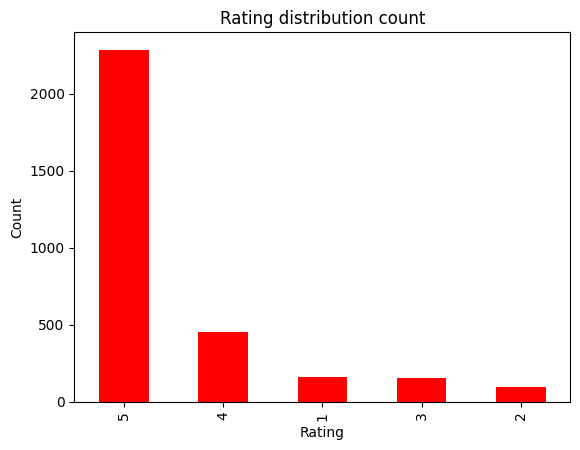

In [26]:
### Lets plot the above values in a bar graph
## Bar plot to visualize the total counts of each rating

data['rating'].value_counts().plot.bar(color='red')
plt.title("Rating distribution count")
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [27]:
data['rating'].value_counts(normalize=True)*100

rating
5    72.594474
4    14.449031
1     5.112734
3     4.826929
2     3.016831
Name: proportion, dtype: float64

In [28]:
# Finding the percentage distribution of each rating - we'll divide the number of record for each rating by total number of 

print(f"Rating value count -percentage distribution: \n{round(data['rating'].value_counts()/data.shape[0]*100,2)}")

Rating value count -percentage distribution: 
rating
5    72.59
4    14.45
1     5.11
3     4.83
2     3.02
Name: count, dtype: float64


In [29]:
data['rating'].value_counts().values

array([2286,  455,  161,  152,   95])

In [30]:
data['rating'].value_counts().index

Index([5, 4, 1, 3, 2], dtype='int64', name='rating')

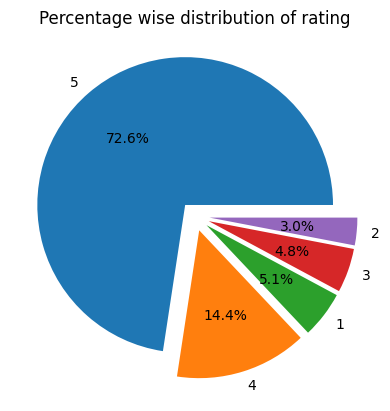

In [31]:
# Ploting a pie chart for the percentage wise distribution of rating
explode = (0.1,0.1,0.1,0.1,0.1)
colors = ('red','green','blue','magenta','yellow')
plt.title("Percentage wise distribution of rating")
wp = {'linewidth':1,'edgecolor':'black'}

plt.pie(data['rating'].value_counts().values,labels=data['rating'].value_counts().index,autopct='%0.1f%%',explode=explode);

In [32]:
data.groupby("rating")['feedback'].value_counts()

rating  feedback
1       0            161
2       0             95
3       1            152
4       1            455
5       1           2286
Name: count, dtype: int64

In [33]:
## Analyzing 'feedback' column
### This column refers to the feedback of the verified review

In [34]:
## Distinct values of 'feedback' and its counts
print (f"feedback value count: \n{data['feedback'].value_counts()}")

feedback value count: 
feedback
1    2893
0     256
Name: count, dtype: int64


In [35]:
# There are 2 distinct values of 'feedback' present- 0 and 1. Lets see what kind of review each value corresponds to.

# feedback value = 0

In [36]:
# Extracting the 'verified_reviews' value for one record with feedback - 0

review_0 = data[data['feedback'] == 0].iloc[3]['verified_reviews']
print(review_0)

Stopped working after 2 weeks ,didn't follow commands!? Really fun when it was working?


In [37]:
data[data['feedback'] ==0 ].iloc[3]['rating']

np.int64(1)

In [38]:
# Extracting the 'verified_reviews' value for one record with feedback - 0

review_1 = data[data['feedback'] == 1].iloc[1]['verified_reviews']
print(review_1)

Loved it!


In [39]:
data[data['feedback'] ==1 ].iloc[1]['rating']

np.int64(5)

In [40]:
## From the above 2 example we can see that feedback 0 is negative review and 1 is positive review
## Lets plot the feedback value counts in a bar graph

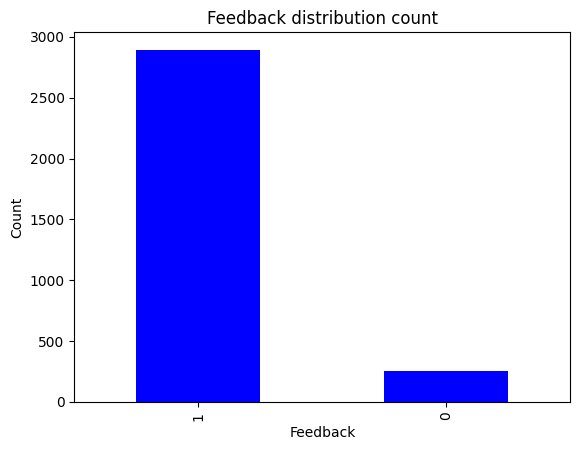

In [41]:
# Bar graph to visualize the total counts of each feedback

data['feedback'].value_counts().plot.bar(color='blue')
plt.title('Feedback distribution count')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

In [42]:
# Finding the percentage distribution of each feedback - we'll divide the number of record for each feedback by total number
print(f"Feedback value count - percentage distribution: \n{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

Feedback value count - percentage distribution: 
feedback
1    91.87
0     8.13
Name: count, dtype: float64


<Axes: ylabel='count'>

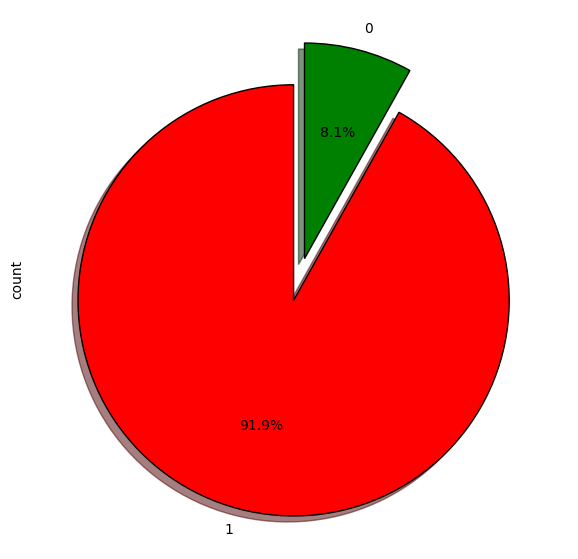

In [43]:
fig = plt.figure(figsize=(7,7))
colors = ('red','green')
wp = {'linewidth':1,"edgecolor":'black'}
tags = data['feedback'].value_counts()/data.shape[0]
explode = (0.1,0.1)
tags.plot(kind='pie',autopct="%1.1f%%",shadow=True,colors=colors,startangle=90,wedgeprops=wp,explode=explode)

In [44]:
### Let see the 'rating' values for different values of 'feedback'

In [45]:
# Feedback = 0
data[data['feedback'] == 0 ]['rating'].value_counts()

rating
1    161
2     95
Name: count, dtype: int64

In [46]:
# Feedback = 1
data[data['feedback'] == 1 ]['rating'].value_counts()

rating
5    2286
4     455
3     152
Name: count, dtype: int64

In [47]:
### If rating is 1 or 2 then the feedback is 0 (negative) and if the rating is 3,4 or 5 then the feedback is 1 (positive).

In [48]:
## Analyzing 'variation' column
### This column refers to the variation or type of Amazon Alexa product. Example - Black Dot, Charcole Fabric etc.

In [49]:
data.groupby("variation")['feedback'].value_counts()

variation                     feedback
Black                         1           226
                              0            35
Black  Dot                    1           480
                              0            36
Black  Plus                   1           242
                              0            28
Black  Show                   1           247
                              0            18
Black  Spot                   1           209
                              0            32
Charcoal Fabric               1           418
                              0            12
Configuration: Fire TV Stick  1           322
                              0            28
Heather Gray Fabric           1           155
                              0             2
Oak Finish                    1            14
Sandstone Fabric              1            84
                              0             6
Walnut Finish                 1             9
White                         1          

In [50]:
# Distinct values of 'variation' and its count

print(f"Variation value count: \n{data['variation'].value_counts()}")

Variation value count: 
variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Sandstone Fabric                 90
White                            90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: count, dtype: int64


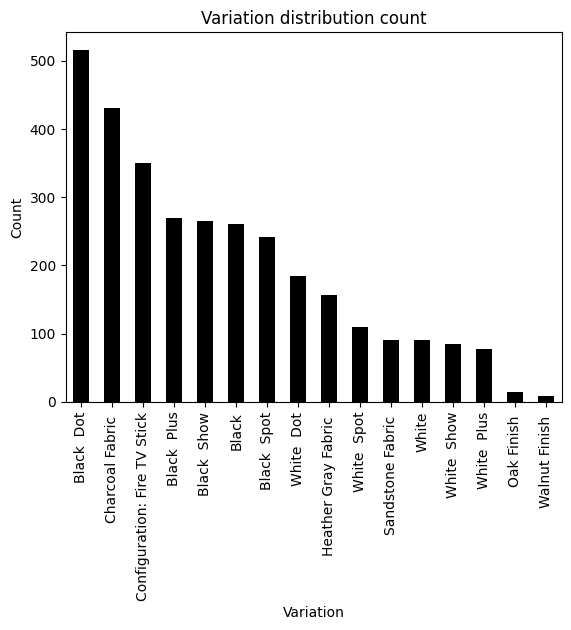

In [51]:
# Bar graph to visualize the total counts of each variation

data['variation'].value_counts().plot.bar(color='k')
plt.title("Variation distribution count")
plt.xlabel('Variation')
plt.ylabel('Count')
plt.show()

In [52]:
# Finding the percentage distribution of each variation - we'll divide the number of record for each variation by total number

print(f"Variation value count - percentage distribution: \n{round(data['variation'].value_counts()/data.shape[0]*100,2)}")

Variation value count - percentage distribution: 
variation
Black  Dot                      16.39
Charcoal Fabric                 13.66
Configuration: Fire TV Stick    11.11
Black  Plus                      8.57
Black  Show                      8.42
Black                            8.29
Black  Spot                      7.65
White  Dot                       5.84
Heather Gray Fabric              4.99
White  Spot                      3.46
Sandstone Fabric                 2.86
White                            2.86
White  Show                      2.70
White  Plus                      2.48
Oak Finish                       0.44
Walnut Finish                    0.29
Name: count, dtype: float64


In [53]:
# Mean rating according to variation

data.groupby('variation')['rating'].mean()

variation
Black                           4.233716
Black  Dot                      4.453488
Black  Plus                     4.370370
Black  Show                     4.490566
Black  Spot                     4.311203
Charcoal Fabric                 4.730233
Configuration: Fire TV Stick    4.591429
Heather Gray Fabric             4.694268
Oak Finish                      4.857143
Sandstone Fabric                4.355556
Walnut Finish                   4.888889
White                           4.166667
White  Dot                      4.423913
White  Plus                     4.358974
White  Show                     4.282353
White  Spot                     4.311927
Name: rating, dtype: float64

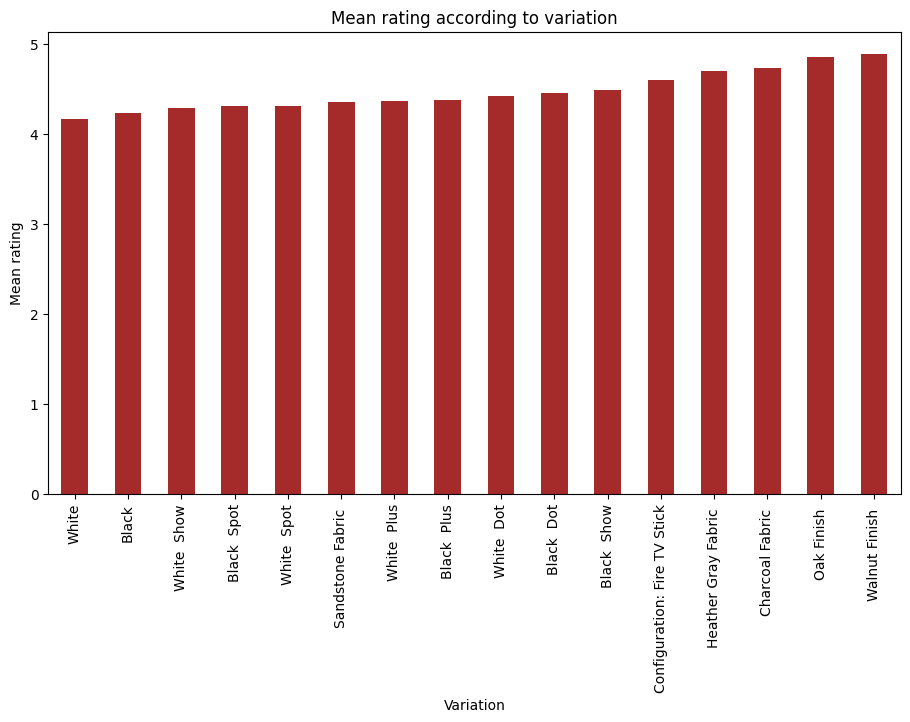

In [54]:
data.groupby('variation')['rating'].mean().sort_values().plot.bar(color='brown',figsize=(11,6))
plt.title("Mean rating according to variation")
plt.xlabel('Variation')
plt.ylabel('Mean rating')
plt.show()

In [55]:
## Analyzing 'verified_reviews' column
### This column contains the textual review given by the user for a variation for the product

In [56]:
data['length'].min()

1

In [57]:
data['length'].describe()

count    3149.000000
mean      132.090187
std       182.114569
min         1.000000
25%        30.000000
50%        74.000000
75%       165.000000
max      2851.000000
Name: length, dtype: float64

[Text(0.5, 1.0, 'Distribution of length of review')]

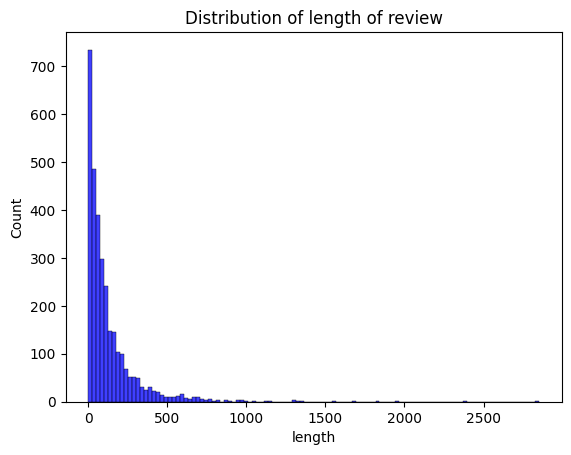

In [58]:
sns.histplot(data['length'],color='blue').set(title='Distribution of length of review')

In [59]:
data['length'].max()

2851

In [60]:
# maximum word review
for i in data[data['length']==data['length'].max()]['verified_reviews']:
    print(i)
    print(data[data['length']==data['length'].max()]['feedback'])

Incredible piece of technology.I have this right center of my living room on an island kitchen counter. The mic and speaker goes in every direction and the quality of the sound is quite good. I connected the Echo via Bluetooth to my Sony soundbar on my TV but find the Echo placement and 360 sound more appealing. It's no audiophile equipment but there is good range and decent bass. The sound is more than adequate for any indoor entertaining and loud enough to bother neighbors in my building. The knob on the top works great for adjusting volume. This is my first Echo device and I would imagine having to press volume buttons (on the Echo 2) a large inconvenience and not as precise. For that alone I would recommend this over the regular Echo (2nd generation).The piece looks quality and is quite sturdy with some weight on it. The rubber material on the bottom has a good grip on the granite counter-- my cat can even rub her scent on it without tipping it over.This order came with a free Phil

In [61]:
for i in data[data['length']==data['length'].max()]['verified_reviews']:
    print(i)
    print("Total Characters in it",data[data['length']==data['length'].max()]['length'])

Incredible piece of technology.I have this right center of my living room on an island kitchen counter. The mic and speaker goes in every direction and the quality of the sound is quite good. I connected the Echo via Bluetooth to my Sony soundbar on my TV but find the Echo placement and 360 sound more appealing. It's no audiophile equipment but there is good range and decent bass. The sound is more than adequate for any indoor entertaining and loud enough to bother neighbors in my building. The knob on the top works great for adjusting volume. This is my first Echo device and I would imagine having to press volume buttons (on the Echo 2) a large inconvenience and not as precise. For that alone I would recommend this over the regular Echo (2nd generation).The piece looks quality and is quite sturdy with some weight on it. The rubber material on the bottom has a good grip on the granite counter-- my cat can even rub her scent on it without tipping it over.This order came with a free Phil

In [62]:
## Length analysis when feedback is 0 (negative)

In [63]:
data[data['length']==data['length'].min()]['verified_reviews'].head(2)

60    😍
85     
Name: verified_reviews, dtype: object

In [64]:
for i in data[data['length']==data['length'].min()]['verified_reviews']:
    print(i)
    print("Total Characters in it",data[data['length']==data['length'].min()]['length'])

😍
Total Characters in it 60      1
85      1
183     1
219     1
374     1
       ..
3114    1
3120    1
3123    1
3126    1
3141    1
Name: length, Length: 81, dtype: int64
 
Total Characters in it 60      1
85      1
183     1
219     1
374     1
       ..
3114    1
3120    1
3123    1
3126    1
3141    1
Name: length, Length: 81, dtype: int64
 
Total Characters in it 60      1
85      1
183     1
219     1
374     1
       ..
3114    1
3120    1
3123    1
3126    1
3141    1
Name: length, Length: 81, dtype: int64
 
Total Characters in it 60      1
85      1
183     1
219     1
374     1
       ..
3114    1
3120    1
3123    1
3126    1
3141    1
Name: length, Length: 81, dtype: int64
 
Total Characters in it 60      1
85      1
183     1
219     1
374     1
       ..
3114    1
3120    1
3123    1
3126    1
3141    1
Name: length, Length: 81, dtype: int64
 
Total Characters in it 60      1
85      1
183     1
219     1
374     1
       ..
3114    1
3120    1
3123    1
3126    1
3141 

[Text(0.5, 1.0, 'Distribution of length of review if feedback = 0 ')]

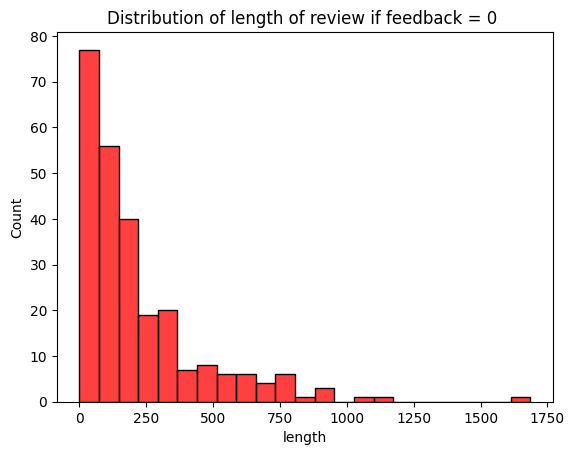

In [65]:
sns.histplot(data[data['feedback']==0]['length'],color='red').set(title="Distribution of length of review if feedback = 0 ")

In [66]:
## Length analysis when feedback is 1 (positive)

[Text(0.5, 1.0, 'Distribution of length of review if feedback = 1 ')]

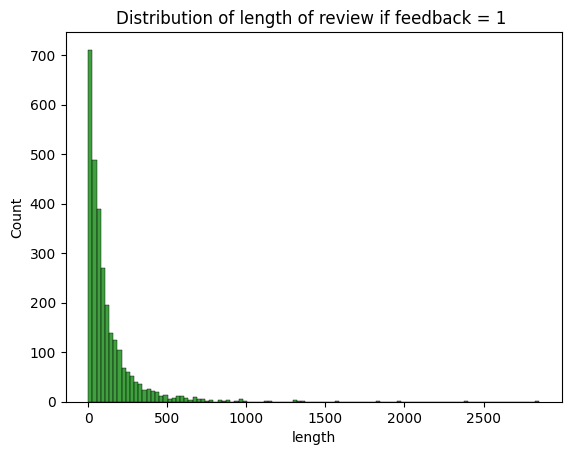

In [67]:
sns.histplot(data[data['feedback']==1]['length'],color='green').set(title="Distribution of length of review if feedback = 1 ")

In [68]:
# Length wise mean rating

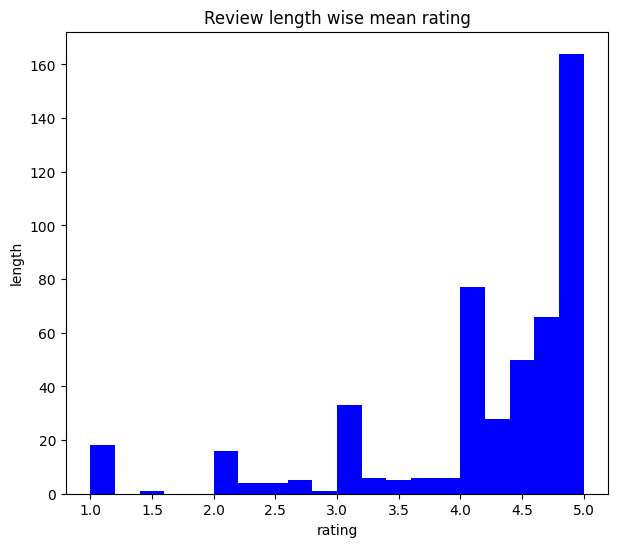

In [69]:
data.groupby('length')['rating'].mean().plot.hist(color='blue',figsize=(7,6),bins=20)
plt.title('Review length wise mean rating')
plt.xlabel('rating')
plt.ylabel('length')
plt.show()

In [70]:
data['verified_reviews']

0                                           Love my Echo!
1                                               Loved it!
2       Sometimes while playing a game, you can answer...
3       I have had a lot of fun with this thing. My 4 ...
4                                                   Music
                              ...                        
3145    Perfect for kids, adults and everyone in betwe...
3146    Listening to music, searching locations, check...
3147    I do love these things, i have them running my...
3148    Only complaint I have is that the sound qualit...
3149                                                 Good
Name: verified_reviews, Length: 3149, dtype: object

In [71]:
reviews = " ".join([review for review in data['verified_reviews']])
reviews

'Love my Echo! Loved it! Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the same as you.  I like being able to turn lights on and off while away from home. I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games like categories. Has nice sound when playing music as well. Music I received the echo as a gift. I needed another Bluetooth or something to play music easily accessible, and found this smart speaker. Can’t wait to see what else it can do. Without having a cellphone, I cannot use many of her features. I have an iPad but do not see that of any use.  It IS a great alarm.  If u r almost deaf, you can hear her alarm in the bedroom from out in the living room, so that is reason enough to keep her.It is fun to ask random questions to hear her response.  She does not seem to be very smartbon politics yet. I think this is the 5th one I\'ve purchased. I\'m working on 

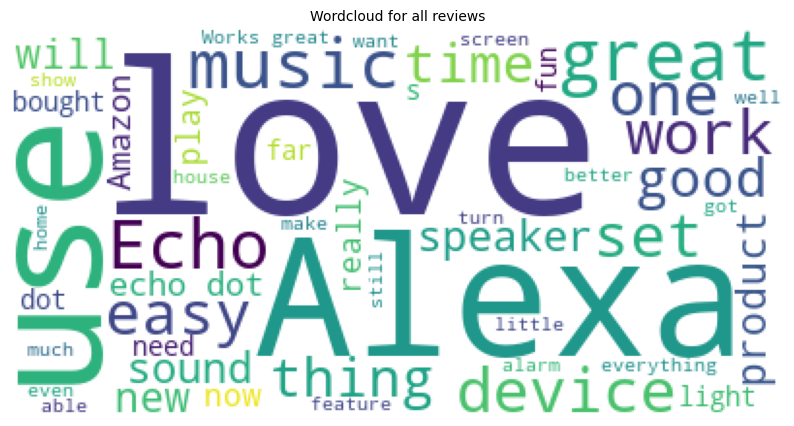

In [72]:
## Combine all reviews
reviews = " ".join([review for review in data['verified_reviews']])

## Initialize wordcloud object
wc = WordCloud(background_color='white',max_words=50)

## Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(reviews))
plt.title('Wordcloud for all reviews', fontsize=10)
plt.axis('off')
plt.show()

In [73]:
## Lets find the unique words in each feedback category

In [74]:
# Combine all reviews for each feedback category and splitting them into individual words
neg_reviews = " ".join([review for review in data[data['feedback']==0]['verified_reviews']])
neg_reviews = neg_reviews.lower().split()

pos_reviews = " ".join([review for review in data[data['feedback']==1]['verified_reviews']])
pos_reviews = pos_reviews.lower().split()

## Finding words from reviews which are present in that feedback category only
unique_negative = [x for x in neg_reviews if x not in pos_reviews]
unique_negative = " ".join(unique_negative)

unique_positive = [x for x in pos_reviews if x not in neg_reviews]
unique_positive = " ".join(unique_positive)


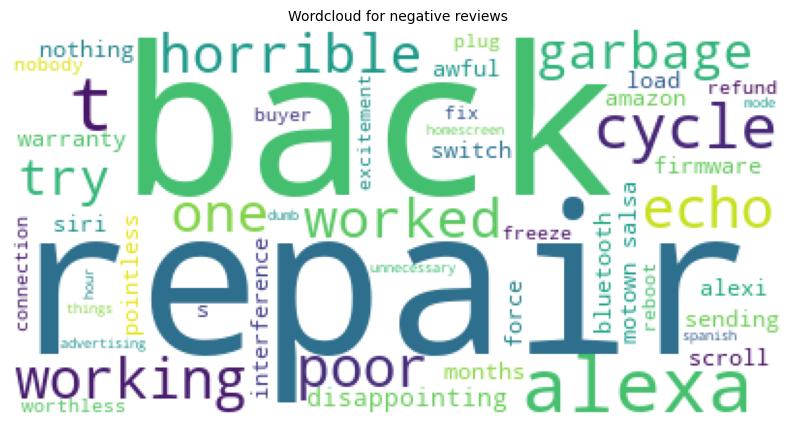

In [75]:
wc = WordCloud(background_color='white',max_words=50)

## Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_negative))
plt.title('Wordcloud for negative reviews',fontsize=10)
plt.axis('off')
plt.show()

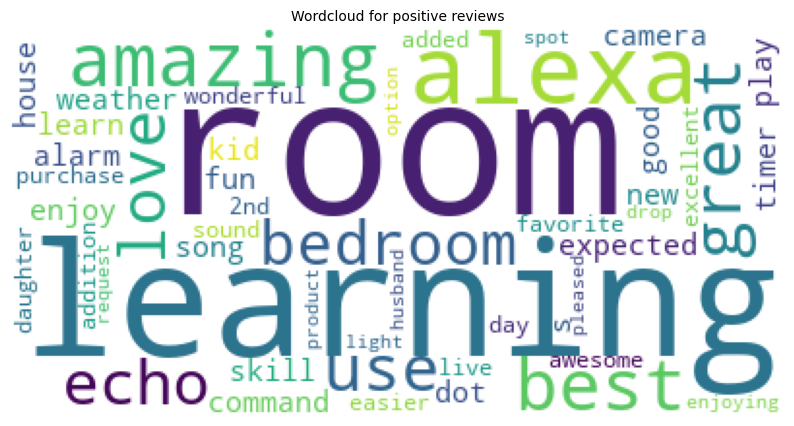

In [76]:
wc = WordCloud(background_color='white',max_words=50)

## Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_positive))
plt.title('Wordcloud for positive reviews',fontsize=10)
plt.axis('off')
plt.show()

## Data Preprocessing
    Lower case
    Tolenization
    Removing Special Characters
    Removing stop words & punctuations
    Stemming (word are converted into root or simple form )

In [77]:
import string
string.punctuation
# from nltk.stem.porter import PorterStemmer
# ps = PorterStemmer()

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [78]:
from nltk.stem import WordNetLemmatizer
wl = WordNetLemmatizer()
# Example
wl.lemmatize('walking',"v")

'walk'

In [79]:
def text_transform(text):
    text=text.lower()     # Converting in lower case
    # print(text)
    text=nltk.word_tokenize(text)        # splitting into word
    # print(text)

    # removing special character
    L = []
    for i in text:
        if i.isalnum():
            L.append(i)
    # print(L)

# Removing stop words and punctuation marks
    text=L.copy()
    L.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            L.append(i)
    # print(L)

# Applying stemming
    text=L.copy()
    L.clear()
    for i in text:
        # L.append(ps.stem(i))
        L.append(wl.lemmatize(i,"v"))
    # print(L)

    return " ".join(L)

In [80]:
text_transform("Stopped working after 2 weeks ,didn't follow commands!? Really fun when it was working?")

'stop work 2 weeks follow command really fun work'

In [81]:
data['text_transformed']=data['verified_reviews'].apply(text_transform)

In [82]:
data

,rating,date,variation,verified_reviews,feedback,length,text_transformed
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13,love echo
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9,love
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,195,sometimes play game answer question correctly ...
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172,lot fun thing 4 yr old learn dinosaurs control...
4,5,31-Jul-18,Charcoal Fabric,Music,1,5,music
...,...,...,...,...,...,...,...
3145,5,30-Jul-18,Black Dot,"Perfect for kids, adults and everyone in betwe...",1,50,perfect kid adults everyone
3146,5,30-Jul-18,Black Dot,"Listening to music, searching locations, check...",1,135,listen music search locations check time look ...
3147,5,30-Jul-18,Black Dot,"I do love these things, i have them running my...",1,441,love things run entire home tv light thermosta...
3148,5,30-Jul-18,White Dot,Only complaint I have is that the sound qualit...,1,380,complaint sound quality great mostly use comma...


## Feature Engineering

In [83]:
x = data['text_transformed']
y = data['feedback']

In [84]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,2))
x = tfidf.fit_transform(data['text_transformed']).toarray()
y = data['feedback'].values

In [85]:
# Splitting data into train and test set with 30% data with testing
from sklearn.model_selection import train_test_split

In [86]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=15)

In [87]:
x

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(3149, 5000))

In [88]:
y

array([1, 1, 1, ..., 1, 1, 1], shape=(3149,))

In [89]:
# Checking the shape of X and Y
print(f"x shape:{x.shape}")
print(f"y shape:{y.shape}")

x shape:(3149, 5000)
y shape:(3149,)


In [90]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2204, 5000)
(945, 5000)
(2204,)
(945,)


In [91]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

print("Before:", Counter(y_train))

ros = RandomOverSampler(random_state=42)
x_resampled, y_resampled = ros.fit_resample(x_train, y_train)

print("After:", Counter(y_resampled))

Before: Counter({np.int64(1): 2026, np.int64(0): 178})
After: Counter({np.int64(1): 2026, np.int64(0): 2026})


In [92]:
# Model Building
# Model Training & Evaluation

In [93]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,recall_score
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [94]:
svc = SVC()
knc = KNeighborsClassifier()
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression()
rfc = RandomForestClassifier(n_estimators=350, random_state=42,max_depth=30)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [95]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'GNB' : gnb,
    'MNB': mnb,
    'BNB': bnb,
    'DT': dtc, 
    'LR': lrc, 
    'RFC': rfc,
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [96]:
clfs.items()

dict_items([('SVC', SVC()), ('KN', KNeighborsClassifier()), ('GNB', GaussianNB()), ('MNB', MultinomialNB()), ('BNB', BernoulliNB()), ('DT', DecisionTreeClassifier(max_depth=5)), ('LR', LogisticRegression()), ('RFC', RandomForestClassifier(max_depth=30, n_estimators=350, random_state=42)), ('AdaBoost', AdaBoostClassifier(random_state=2)), ('BgC', BaggingClassifier(n_estimators=50, random_state=2)), ('ETC', ExtraTreesClassifier(n_estimators=50, random_state=2)), ('GBDT', GradientBoostingClassifier(n_estimators=50, random_state=2)), ('xgb', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None

In [97]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_resampled, y_resampled)
    y_pred_test = clf.predict(x_test)
    y_pred_train = clf.predict(x_train)

    accuracy_test = accuracy_score(y_test,y_pred_test)
    accuracy_train = accuracy_score(y_train,y_pred_train)
    precision_scores_train = precision_score(y_train,y_pred_train)
    precision_scores_test = precision_score(y_test,y_pred_test)
    recall_score_train = recall_score(y_train,y_pred_train)
    recall_score_test = recall_score(y_test,y_pred_test)
    confusion_matrix_test = confusion_matrix(y_test,y_pred_test)
    confusion_matrix_train = confusion_matrix(y_train,y_pred_train)
    
    
    return accuracy_train,accuracy_test,precision_scores_train,precision_scores_test,recall_score_train,recall_score_test,confusion_matrix_train,confusion_matrix_test

In [98]:
for name,clf in clfs.items():
    
    accuracy_train,accuracy_test,precision_score_train,precision_score_test,recall_score_train,recall_score_test,confusion_matrix_train,confusion_matrix_test = train_classifier(clf, x_train,y_train,x_test,y_test)
    
    print("For ",name)
    print("Training Accuracy - ",accuracy_train)
    print("Testing Accuracy - ",accuracy_test)
    print("Precision Score Training ",precision_score_train)
    print("Precision Score Testing ",precision_score_test)
    print("Recall Score Training ",recall_score_train)
    print("Recall Score Testing ",recall_score_test)
    print("Confusion Matrix Training \n",confusion_matrix_train)
    print("Confusion Matrix Testing \n",confusion_matrix_test)
    print()

For  SVC
Training Accuracy -  0.9682395644283122
Testing Accuracy -  0.9333333333333333
Precision Score Training  1.0
Precision Score Testing  0.9527027027027027
Recall Score Training  0.9654491609081934
Recall Score Testing  0.9757785467128027
Confusion Matrix Training 
 [[ 178    0]
 [  70 1956]]
Confusion Matrix Testing 
 [[ 36  42]
 [ 21 846]]

For  KN
Training Accuracy -  0.9900181488203267
Testing Accuracy -  0.9312169312169312
Precision Score Training  0.9940828402366864
Precision Score Testing  0.9358695652173913
Recall Score Training  0.9950641658440277
Recall Score Testing  0.9930795847750865
Confusion Matrix Training 
 [[ 166   12]
 [  10 2016]]
Confusion Matrix Testing 
 [[ 19  59]
 [  6 861]]

For  GNB
Training Accuracy -  0.838929219600726
Testing Accuracy -  0.8275132275132275
Precision Score Training  1.0
Precision Score Testing  0.9536082474226805
Recall Score Training  0.8247778874629812
Recall Score Testing  0.8535178777393311
Confusion Matrix Training 
 [[ 178    0]

In [99]:
# Random Forest achieved the best performance with 95.34% accuracy, perfect precision, and near-perfect recall.

In [100]:
# Saving the best performance model as Random Forest Classifier

In [101]:
import pickle

In [102]:
pickle.dump(tfidf,open('alexa_review_vectorizer_tfidf.pkl','wb'))
pickle.dump(rfc,open('alexa_review_model_rfc.pkl','wb'))